In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Verilerin yüklenmesi

In [11]:
df = pd.read_csv('missense_mutations.csv')
df_filtered = df[df['ClinSigSimple'].isin([0, 1])].copy()
df_filtered

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
1,24368,single nucleotide variant,NM_000059.4(BRCA2):c.1114A>C (p.Asn372His),675,BRCA2,HGNC:1101,Benign,0,"Jan 12, 2015",144848,...,C,-,-,-,-,-,-,SCV000245002,-,-
2,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
3,24379,single nucleotide variant,NM_000059.4(BRCA2):c.8165C>G (p.Thr2722Arg),675,BRCA2,HGNC:1101,Pathogenic,1,"Aug 10, 2015",80359062,...,G,-,-,-,-,-,-,SCV000244480,-,-
4,24384,single nucleotide variant,NM_000059.4(BRCA2):c.7529T>C (p.Leu2510Pro),675,BRCA2,HGNC:1101,Pathogenic/Likely pathogenic,1,"Jul 09, 2024",80358979,...,C,-,-,-,-,-,-,SCV000567107|SCV000607817|SCV001478276|SCV0015...,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,4185255,single nucleotide variant,NM_000059.4(BRCA2):c.8754G>C (p.Glu2918Asp),675,BRCA2,HGNC:1101,Likely pathogenic,1,"Jun 12, 2025",-1,...,C,-,-,-,-,-,-,SCV006298678,-,-
11230,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11231,4198803,single nucleotide variant,NM_000059.4(BRCA2):c.1307A>G (p.Lys436Arg),675,BRCA2,HGNC:1101,Uncertain significance,0,-,-1,...,G,-,-,-,-,-,-,SCV006333499,-,-
11232,4391609,single nucleotide variant,NM_007294.4(BRCA1):c.298G>C (p.Glu100Gln),672,BRCA1,HGNC:1100,Uncertain significance,0,"Jul 31, 2025",-1,...,G,-,-,-,-,-,-,SCV006554521,-,-


In [5]:
print(df_filtered['ClinSigSimple'].value_counts(normalize=True))

ClinSigSimple
0    0.907679
1    0.092321
Name: proportion, dtype: float64


In [6]:
df_majority = df_filtered[df_filtered.ClinSigSimple == 0] # Benign
df_minority = df_filtered[df_filtered.ClinSigSimple == 1] # Pathogenic

In [8]:
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    
                                 n_samples=len(df_minority),
                                 random_state=42)

In [9]:
df_balanced = pd.concat([df_majority_downsampled, df_minority])
print(f"Eşitlenmiş Dağılım: {df_balanced['ClinSigSimple'].value_counts().to_dict()}")

Eşitlenmiş Dağılım: {0: 832, 1: 832}


Özelliklerin çıkartılması (Kullanılacak sütunların belirlenmesi)

In [10]:
features = ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
X = df_balanced[features].copy()
y = df_balanced['ClinSigSimple'].values

Kategorik verilerin sayısallaştırılması

In [12]:
le = LabelEncoder()
for col in ['GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']:
    X[col] = le.fit_transform(X[col].astype(str))

Ölçeklendirme işlemi

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Verinin giriş boyutunun belirlenmesi

In [14]:
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

Modelin eğitim / test olarak ayrılması

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42, stratify=y)

Modelin oluşturulması

In [17]:
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # İkili sınıflandırma çıktısı
])

C:\Users\emirh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Modelin eğitilmesi

In [19]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5942 - loss: 0.6802 - val_accuracy: 0.6866 - val_loss: 0.6183
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6147 - loss: 0.6567 - val_accuracy: 0.6866 - val_loss: 0.5941
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6154 - loss: 0.6497 - val_accuracy: 0.6866 - val_loss: 0.5845
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6154 - loss: 0.6440 - val_accuracy: 0.7313 - val_loss: 0.5777
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6568 - loss: 0.6263 - val_accuracy: 0.7388 - val_loss: 0.5931
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6216 - loss: 0.6415 - val_accuracy: 0.7313 - val_loss: 0.5766
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6554 - loss: 0.6230 - val_accuracy: 0.7388 - val_loss: 0.5879
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6258 - loss: 0.6460 - val_accuracy: 0.7313 - val_loss:

Modelin değerlendirilmesi

In [23]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.64      0.63       167
           1       0.63      0.61      0.62       166

    accuracy                           0.63       333
   macro avg       0.63      0.63      0.63       333
weighted avg       0.63      0.63      0.63       333



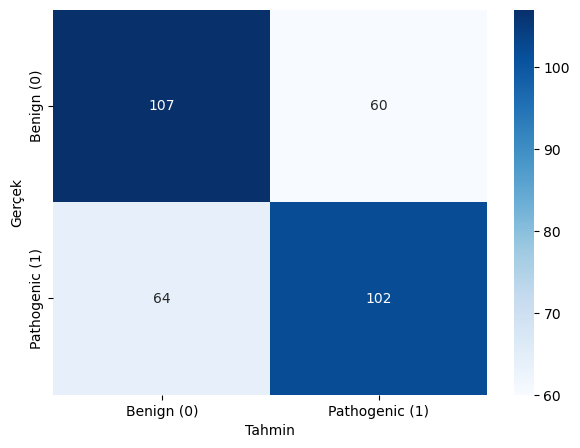

In [26]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Pathogenic (1)'], 
            yticklabels=['Benign (0)', 'Pathogenic (1)'])
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

In [28]:
acc = accuracy_score(y_test, y_pred)
acc

0.6276276276276276